# BioSentinel India — Person 3: AI & Anomaly Intelligence

**Owner:** Person 3

This notebook contains the Person 3 technical pipeline:

1. Effort-aware anomaly feature construction
2. Statistical anomaly detection
3. Isolation Forest anomaly detection
4. Anomaly sensitivity and stability diagnostics
5. Explainable priority scoring
6. Spatial visualization of flagged Grid × Year units
7. EfficientNet-B0 transfer learning for biodiversity image species identification
8. Model evaluation and checkpoint export

### Interpretation rule

The anomaly pipeline identifies **potentially unusual observation-derived biodiversity patterns**. An anomaly is **not** interpreted as direct evidence of biodiversity loss, recovery, population decline, or ecological damage.

Sampling effort, historical baseline support, and data quality are carried forward from Persons 1 and 2.

The image-classification pipeline is a separate component: it predicts species from images and reports standard machine-learning evaluation metrics.


## Pipeline overview

```text
Person 1 biodiversity indicators
        +
Person 2 spatial-temporal analysis
        ↓
Effort-aware feature engineering
        ↓
Statistical anomaly evidence
        +
Isolation Forest
        ↓
Combined anomaly evidence
        ↓
Persistence + coverage
        ↓
Explainable priority score
```

The image branch is independent of the Grid × Year anomaly branch:

```text
Biodiversity images
        ↓
Dataset audit
        ↓
Image preprocessing / augmentation
        ↓
EfficientNet-B0 transfer learning
        ↓
Validation + test evaluation
        ↓
Species + confidence
```


## 1. Setup, paths, and configuration

In [5]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    top_k_accuracy_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# -----------------------------
# Project paths
# -----------------------------
def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find the BioSentinel project root containing data/ and notebooks/."
    )

PROJECT_ROOT = find_project_root()

ANALYTICS_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "analytics"
)

SPATIOTEMPORAL_PATH = (
    ANALYTICS_DIR
    / "grid_year_spatial_temporal_intelligence.parquet"
)

GBIF_TERRESTRIAL_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "gbif_terrestrial_species_year_grid.parquet"
)

IMAGE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "inaturalist"
    / "images"
)

MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = ANALYTICS_DIR / "person3"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Analysis configuration
# -----------------------------
ANALYSIS_START_YEAR = 2018
ANALYSIS_END_YEAR = 2024
MODEL_TRAIN_END_YEAR = 2023

MIN_OCCURRENCES_FOR_COMPARISON = 25
MIN_BASELINE_YEARS = 3

ROBUST_DEVIATION_THRESHOLD = 3.0
ANOMALY_PERCENTILE_THRESHOLD = 95.0

IF_CONTAMINATION = 0.05
IF_RANDOM_STATE = 42

# Priority-score weights
W_ANOMALY = 0.55
W_COMPOSITION = 0.15
W_PERSISTENCE = 0.15
W_COVERAGE = 0.15

print("Project root:", PROJECT_ROOT)
print("Spatio-temporal input:", SPATIOTEMPORAL_PATH)
print("GBIF terrestrial input:", GBIF_TERRESTRIAL_PATH)
print("Image dataset path:", IMAGE_ROOT)
print(f"Analysis period: {ANALYSIS_START_YEAR}-{ANALYSIS_END_YEAR}")
print(f"Isolation Forest training period: {ANALYSIS_START_YEAR}-{MODEL_TRAIN_END_YEAR}")

# Final 30-images/species EfficientNet manifest.
IMAGE_MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "inaturalist"
    / "efficientnet_30_reuse_manifest.csv"
)


Project root: d:\Biosential_India
Spatio-temporal input: d:\Biosential_India\data\processed\analytics\grid_year_spatial_temporal_intelligence.parquet
GBIF terrestrial input: d:\Biosential_India\data\processed\gbif_terrestrial_species_year_grid.parquet
Image dataset path: d:\Biosential_India\data\raw\inaturalist\images
Analysis period: 2018-2024
Isolation Forest training period: 2018-2023


## 2. Load Person 2's finalized spatial-temporal dataset

In [6]:
REQUIRED_COLUMNS = [
    "eqdcellcode",
    "year",
    "total_occurrences",
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "sampling_adequate",
    "sampling_flag",
    "baseline_years",
    "baseline_start_year",
    "baseline_end_year",
    "baseline_richness_median",
    "baseline_richness_mean",
    "baseline_richness_q1",
    "baseline_richness_q3",
    "baseline_iqr",
    "baseline_supported",
    "richness_deviation_from_baseline",
    "baseline_relative_change_pct",
    "baseline_flag",
]

if not SPATIOTEMPORAL_PATH.exists():
    raise FileNotFoundError(
        f"Person 2 output not found: {SPATIOTEMPORAL_PATH}"
    )

pf = pq.ParquetFile(SPATIOTEMPORAL_PATH)

missing = sorted(
    set(REQUIRED_COLUMNS) - set(pf.schema.names)
)

if missing:
    raise ValueError(
        f"Person 2 dataset is missing required columns: {missing}"
    )

data = pd.read_parquet(
    SPATIOTEMPORAL_PATH,
    columns=REQUIRED_COLUMNS,
)

data["year"] = pd.to_numeric(data["year"], errors="raise").astype(int)
data["total_occurrences"] = pd.to_numeric(
    data["total_occurrences"], errors="raise"
)
data["species_richness"] = pd.to_numeric(
    data["species_richness"], errors="raise"
)

data = data[
    data["year"].between(
        ANALYSIS_START_YEAR,
        ANALYSIS_END_YEAR,
    )
].copy()

print("Rows:", f"{len(data):,}")
print("Grid cells:", f"{data['eqdcellcode'].nunique():,}")
print("Years:", sorted(data["year"].unique()))
print(
    "Underlying observation records:",
    f"{data['total_occurrences'].sum():,}"
)

print("\nSampling flags:")
print(data["sampling_flag"].value_counts(dropna=False))

print("\nBaseline flags:")
print(data["baseline_flag"].value_counts(dropna=False))


Rows: 27,830
Grid cells: 6,457
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Underlying observation records: 51,604,362

Sampling flags:
sampling_flag
usable_with_caution    18772
data_limited            9058
Name: count, dtype: int64

Baseline flags:
baseline_flag
baseline_supported                 12913
data_limited_current_year           9058
insufficient_historical_support     5859
Name: count, dtype: int64


## 3. Define eligible anomaly-analysis units

In [7]:
eligible = data[
    data["sampling_adequate"].fillna(False).astype(bool)
    & data["baseline_supported"].fillna(False).astype(bool)
].copy()

if eligible.empty:
    raise ValueError(
        "No eligible Grid × Year units are available for anomaly analysis."
    )

eligible = eligible.sort_values(
    ["eqdcellcode", "year"]
).reset_index(drop=True)

print(
    "Eligible Grid × Year units:",
    f"{len(eligible):,}"
)
print(
    "Eligible grid cells:",
    f"{eligible['eqdcellcode'].nunique():,}"
)
print(
    "Eligible years:",
    sorted(eligible["year"].unique())
)


Eligible Grid × Year units: 12,913
Eligible grid cells: 2,773
Eligible years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 4. Effort-aware anomaly features

### Features

- `richness_iqr_scaled_deviation`: deviation from the grid-specific historical median, scaled by the historical IQR.
- `effort_adjusted_richness_residual`: residual after modelling observed richness against log observation effort.
- `composition_proxy`: magnitude of changes in Shannon diversity, Simpson diversity, and Pielou evenness.
- `consecutive_year`: whether a previous row represents the immediately preceding year.

These are deliberately observation-aware features. The `occurrences` field represents GBIF records, so it is treated as observation effort rather than animal abundance.


In [8]:
# Historical-baseline deviation
eligible["baseline_iqr_safe"] = eligible["baseline_iqr"].fillna(0).clip(lower=1)

eligible["richness_iqr_scaled_deviation"] = (
    eligible["richness_deviation_from_baseline"]
    / eligible["baseline_iqr_safe"]
)

eligible["abs_richness_iqr_scaled_deviation"] = (
    eligible["richness_iqr_scaled_deviation"].abs()
)

# Log observation effort
eligible["log_observation_effort"] = np.log1p(
    eligible["total_occurrences"].clip(lower=0)
)

# Consecutive-year changes within a grid cell
grouped = eligible.groupby("eqdcellcode", sort=False)

eligible["previous_year"] = grouped["year"].shift(1)
eligible["year_gap"] = (
    eligible["year"] - eligible["previous_year"]
)

eligible["consecutive_year"] = eligible["year_gap"].eq(1)

for col in [
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
]:
    eligible[f"previous_{col}"] = grouped[col].shift(1)
    eligible[f"delta_{col}"] = np.where(
        eligible["consecutive_year"],
        eligible[col] - eligible[f"previous_{col}"],
        np.nan,
    )
    eligible[f"abs_delta_{col}"] = eligible[f"delta_{col}"].abs()

eligible["composition_proxy_raw"] = (
    eligible["abs_delta_shannon_diversity"].fillna(0)
    + eligible["abs_delta_simpson_diversity"].fillna(0)
    + eligible["abs_delta_pielou_evenness"].fillna(0)
) / 3.0

print("Feature columns created.")
eligible[
    [
        "eqdcellcode",
        "year",
        "species_richness",
        "total_occurrences",
        "richness_iqr_scaled_deviation",
        "composition_proxy_raw",
    ]
].head(10)


Feature columns created.


,eqdcellcode,year,species_richness,total_occurrences,richness_iqr_scaled_deviation,composition_proxy_raw
0,E068N22DB,2021,163,1565,3.272727,0.000000
1,E068N22DB,2022,114,508,-0.909091,0.068877
2,E068N22DB,2023,176,1789,2.882353,0.083183
3,E068N22DB,2024,156,1744,0.715232,0.037417
4,E068N22DD,2021,85,200,2.074074,0.000000
5,E068N22DD,2022,32,53,-1.555556,0.342336
6,E068N22DD,2023,111,598,2.000000,0.373419
7,E068N22DD,2024,98,360,0.992806,0.046181
8,E068N23BA,2024,42,135,-0.127660,0.000000
9,E068N23BB,2023,63,226,0.607595,0.000000


## 5. Model observation effort and calculate effort-adjusted richness

A simple regression is fit only on the historical training period (`2018–2023`). Its purpose is not ecological prediction; it estimates how observed species richness changes with observation volume in this dataset.

The residual is then used as one piece of anomaly evidence.


In [9]:
train_effort = eligible[
    eligible["year"].between(
        ANALYSIS_START_YEAR,
        MODEL_TRAIN_END_YEAR,
    )
].copy()

if len(train_effort) < 20:
    raise ValueError(
        f"Too few historical training rows for effort model: {len(train_effort)}"
    )

X_effort = train_effort[
    ["log_observation_effort"]
].to_numpy()

y_effort = train_effort[
    "species_richness"
].to_numpy()

effort_model = LinearRegression()
effort_model.fit(X_effort, y_effort)

eligible["predicted_richness_from_effort"] = effort_model.predict(
    eligible[["log_observation_effort"]].to_numpy()
)

eligible["effort_adjusted_richness_residual"] = (
    eligible["species_richness"]
    - eligible["predicted_richness_from_effort"]
)

print(
    "Effort model coefficient:",
    float(effort_model.coef_[0])
)
print(
    "Effort model intercept:",
    float(effort_model.intercept_)
)

print("\nTraining residual statistics:")
print(
    train_effort.assign(
        residual=lambda d:
            d["species_richness"]
            - effort_model.predict(
                d[["log_observation_effort"]].to_numpy()
            )
    )["residual"].describe()
)


Effort model coefficient: 48.010402334442496
Effort model intercept: -172.66566487628845

Training residual statistics:
count    1.028300e+04
mean    -7.960179e-15
std      5.208573e+01
min     -2.243141e+02
25%     -2.501938e+01
50%     -2.051739e+00
75%      1.913127e+01
max      1.119123e+03
Name: residual, dtype: float64


## 6. Statistical anomaly evidence

In [10]:
def percentile_scores(values, reference):
    """
    Return empirical percentile scores in [0, 100].
    Higher values receive higher scores.
    """
    values = np.asarray(values, dtype=float)
    reference = np.asarray(reference, dtype=float)

    reference = reference[np.isfinite(reference)]

    if reference.size == 0:
        return np.full(values.shape, np.nan)

    reference = np.sort(reference)

    positions = np.searchsorted(
        reference,
        values,
        side="right",
    )

    return (
        positions
        / reference.size
        * 100.0
    )


train_mask = eligible["year"].between(
    ANALYSIS_START_YEAR,
    MODEL_TRAIN_END_YEAR,
)

train_reference = eligible.loc[train_mask].copy()

if train_reference.empty:
    raise ValueError("No historical reference rows available.")

# Component 1: baseline deviation
eligible["baseline_anomaly_score"] = np.clip(
    eligible["abs_richness_iqr_scaled_deviation"]
    / ROBUST_DEVIATION_THRESHOLD
    * 100,
    0,
    100,
)

# Component 2: effort-adjusted residual
train_abs_residual = train_reference[
    "effort_adjusted_richness_residual"
].abs()

eligible["effort_residual_score"] = percentile_scores(
    eligible["effort_adjusted_richness_residual"].abs(),
    train_abs_residual,
)

# Component 3: diversity/composition change
train_composition = train_reference[
    "composition_proxy_raw"
]

eligible["composition_change_score"] = percentile_scores(
    eligible["composition_proxy_raw"],
    train_composition,
)

eligible["statistical_anomaly_score"] = (
    0.50 * eligible["baseline_anomaly_score"]
    + 0.30 * eligible["effort_residual_score"]
    + 0.20 * eligible["composition_change_score"]
)

print(
    eligible[
        [
            "baseline_anomaly_score",
            "effort_residual_score",
            "composition_change_score",
            "statistical_anomaly_score",
        ]
    ].describe()
)


       baseline_anomaly_score  effort_residual_score  \
count            12913.000000           12913.000000   
mean                43.504127              49.928184   
std                 31.906696              28.938117   
min                  0.000000               0.000000   
25%                 17.204301              24.730137   
50%                 35.555556              49.761743   
75%                 65.765766              75.075367   
max                100.000000             100.000000   

       composition_change_score  statistical_anomaly_score  
count              12913.000000               12913.000000  
mean                  54.323091                  47.595137  
std                   24.165235                  19.605949  
min                   26.480599                   5.462414  
25%                   27.686473                  32.522865  
50%                   51.444131                  44.800156  
75%                   75.678304                  60.997115  
max    

## 7. Isolation Forest anomaly detection

Isolation Forest provides a second, unsupervised source of anomaly evidence.

It is trained only on eligible historical observations through 2023, then used to score all eligible years including 2024.

There is no ground-truth anomaly label in the current dataset, so conventional classification accuracy is not claimed for this unsupervised stage. Stability and sensitivity diagnostics are reported instead.


In [11]:
MODEL_FEATURES = [
    "species_richness",
    "log_observation_effort",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "richness_iqr_scaled_deviation",
    "effort_adjusted_richness_residual",
    "composition_proxy_raw",
    "baseline_years",
]

model_data = eligible.dropna(
    subset=MODEL_FEATURES
).copy()

train_model = model_data[
    model_data["year"].between(
        ANALYSIS_START_YEAR,
        MODEL_TRAIN_END_YEAR,
    )
].copy()

if len(train_model) < 50:
    raise ValueError(
        f"Too few rows for Isolation Forest training: {len(train_model)}"
    )

scaler = StandardScaler()

X_train = scaler.fit_transform(
    train_model[MODEL_FEATURES]
)

X_all = scaler.transform(
    model_data[MODEL_FEATURES]
)

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=IF_CONTAMINATION,
    random_state=IF_RANDOM_STATE,
    n_jobs=-1,
)

isolation_forest.fit(X_train)

train_raw_if = -isolation_forest.decision_function(
    X_train
)

all_raw_if = -isolation_forest.decision_function(
    X_all
)

model_data["isolation_raw_score"] = all_raw_if

model_data["isolation_anomaly_score"] = percentile_scores(
    all_raw_if,
    train_raw_if,
)

model_data["isolation_outlier_prediction"] = (
    isolation_forest.predict(X_all) == -1
)

# Put IF outputs back into eligible
eligible = eligible.merge(
    model_data[
        [
            "eqdcellcode",
            "year",
            "isolation_raw_score",
            "isolation_anomaly_score",
            "isolation_outlier_prediction",
        ]
    ],
    on=["eqdcellcode", "year"],
    how="left",
    validate="one_to_one",
)

eligible["combined_anomaly_score"] = (
    0.60 * eligible["statistical_anomaly_score"]
    + 0.40 * eligible["isolation_anomaly_score"]
)

eligible["preliminary_anomaly_flag"] = (
    (eligible["combined_anomaly_score"] >= ANOMALY_PERCENTILE_THRESHOLD)
    | (
        eligible["abs_richness_iqr_scaled_deviation"]
        >= ROBUST_DEVIATION_THRESHOLD
    )
)

print(
    "Historical model rows:",
    f"{len(train_model):,}"
)
print(
    "Total eligible rows scored:",
    f"{len(eligible):,}"
)
print(
    "Preliminary anomaly flags:",
    f"{eligible['preliminary_anomaly_flag'].sum():,}"
)


Historical model rows: 10,283
Total eligible rows scored: 12,913
Preliminary anomaly flags: 1,736


## 8. Persistence of anomaly signals

A single unusual observation can reflect sampling variability. Persistence therefore records whether a similar anomaly signal was also present in the immediately preceding one or two years for the same grid cell.

This is a persistence measure, not proof of a sustained ecological change.


In [12]:
eligible = eligible.sort_values(
    ["eqdcellcode", "year"]
).reset_index(drop=True)

grouped = eligible.groupby("eqdcellcode", sort=False)

prev_year_1 = grouped["year"].shift(1)
prev_year_2 = grouped["year"].shift(2)

prev_anomaly_1 = grouped["preliminary_anomaly_flag"].shift(1)
prev_anomaly_2 = grouped["preliminary_anomaly_flag"].shift(2)

valid_prev_1 = eligible["year"].sub(prev_year_1).eq(1)
valid_prev_2 = eligible["year"].sub(prev_year_2).eq(2)

eligible["previous_year_anomaly"] = (
    valid_prev_1
    & prev_anomaly_1.fillna(False).astype(bool)
)

eligible["two_years_previous_anomaly"] = (
    valid_prev_2
    & prev_anomaly_2.fillna(False).astype(bool)
)

eligible["persistence_count"] = (
    eligible["previous_year_anomaly"].astype(int)
    + eligible["two_years_previous_anomaly"].astype(int)
)

eligible["persistence_score"] = (
    eligible["persistence_count"]
    / 2.0
    * 100.0
)

eligible["persistence_score"] = eligible[
    "persistence_score"
].clip(0, 100)

eligible[
    [
        "eqdcellcode",
        "year",
        "preliminary_anomaly_flag",
        "previous_year_anomaly",
        "two_years_previous_anomaly",
        "persistence_score",
    ]
].head(15)


,eqdcellcode,year,preliminary_anomaly_flag,previous_year_anomaly,two_years_previous_anomaly,persistence_score
0,E068N22DB,2021,True,False,False,0.0
1,E068N22DB,2022,False,True,False,50.0
2,E068N22DB,2023,False,False,True,50.0
3,E068N22DB,2024,False,False,False,0.0
4,E068N22DD,2021,False,False,False,0.0
5,E068N22DD,2022,False,False,False,0.0
6,E068N22DD,2023,False,False,False,0.0
7,E068N22DD,2024,False,False,False,0.0
8,E068N23BA,2024,False,False,False,0.0
9,E068N23BB,2023,False,False,False,0.0


## 9. Coverage confidence

Coverage is kept separate from anomaly magnitude.

Higher observation effort and more historical support increase confidence that an observation-derived signal is sufficiently supported. They do **not** mean that the ecological state itself is healthier or more important.


In [13]:
train_log_effort = train_reference[
    "log_observation_effort"
]

eligible["observation_effort_coverage_score"] = percentile_scores(
    eligible["log_observation_effort"],
    train_log_effort,
)

# Baseline support is capped at the maximum historical support available
# in the current comparison window.
max_baseline_years = max(
    int(ANALYSIS_END_YEAR - ANALYSIS_START_YEAR),
    MIN_BASELINE_YEARS,
)

eligible["historical_support_score"] = (
    eligible["baseline_years"]
    .fillna(0)
    / max_baseline_years
    * 100
).clip(0, 100)

eligible["coverage_score"] = (
    0.60 * eligible["observation_effort_coverage_score"]
    + 0.40 * eligible["historical_support_score"]
)

eligible["evidence_confidence_score"] = np.where(
    eligible["sampling_adequate"].fillna(False)
    & eligible["baseline_supported"].fillna(False),
    eligible["coverage_score"],
    0,
)

print(
    eligible[
        [
            "observation_effort_coverage_score",
            "historical_support_score",
            "coverage_score",
        ]
    ].describe()
)


       observation_effort_coverage_score  historical_support_score  \
count                       12913.000000              12913.000000   
mean                           50.014457                 80.156948   
std                            29.031435                 20.010052   
min                             0.243120                 50.000000   
25%                            24.642614                 66.666667   
50%                            49.946514                 83.333333   
75%                            75.250413                100.000000   
max                           100.000000                100.000000   

       coverage_score  
count    12913.000000  
mean        62.071453  
std         21.722683  
min         20.145872  
25%         44.179714  
50%         62.636066  
75%         80.184771  
max        100.000000  


## 10. Explainable priority score

The priority score combines:

- anomaly evidence
- diversity/composition change proxy
- persistence
- sampling coverage

It is a **screening/prioritization score for further investigation**, not a conservation verdict.


In [14]:
eligible["priority_score"] = (
    W_ANOMALY * eligible["combined_anomaly_score"]
    + W_COMPOSITION * eligible["composition_change_score"]
    + W_PERSISTENCE * eligible["persistence_score"]
    + W_COVERAGE * eligible["coverage_score"]
).clip(0, 100)

# Keep all components explicit for explainability.
eligible["priority_score"] = eligible[
    "priority_score"
].round(2)

def build_explanation(row):
    reasons = []

    rel = row["baseline_relative_change_pct"]

    if pd.notna(rel):
        if rel <= -20:
            reasons.append(
                f"observed richness is {abs(rel):.1f}% below its historical median"
            )
        elif rel >= 20:
            reasons.append(
                f"observed richness is {rel:.1f}% above its historical median"
            )
        else:
            reasons.append(
                "observed richness is close to its historical median"
            )

    if row["composition_change_score"] >= 75:
        reasons.append(
            "diversity/evenness indicators changed substantially"
        )
    elif row["composition_change_score"] >= 50:
        reasons.append(
            "diversity/evenness indicators show a notable change"
        )

    if row["persistence_count"] >= 2:
        reasons.append(
            "anomaly signal persisted across the previous two consecutive years"
        )
    elif row["persistence_count"] == 1:
        reasons.append(
            "a similar anomaly signal was present in the immediately preceding year"
        )

    if row["coverage_score"] < 30:
        reasons.append(
            "sampling support is limited, reducing confidence"
        )
    elif row["coverage_score"] >= 70:
        reasons.append(
            "sampling and historical support are comparatively strong"
        )
    else:
        reasons.append(
            "sampling support is moderate"
        )

    if row["isolation_outlier_prediction"]:
        reasons.append(
            "Isolation Forest also classified the unit as an outlier"
        )

    return "; ".join(reasons)

eligible["priority_reason"] = eligible.apply(
    build_explanation,
    axis=1,
)

print(
    eligible[
        [
            "eqdcellcode",
            "year",
            "combined_anomaly_score",
            "persistence_score",
            "coverage_score",
            "priority_score",
            "priority_reason",
        ]
    ]
    .sort_values("priority_score", ascending=False)
    .head(10)
    .to_string(index=False)
)


eqdcellcode  year  combined_anomaly_score  persistence_score  coverage_score  priority_score                                                                                                                                                                                                                                                                                     priority_reason
  E091N23AB  2024               96.154819              100.0       98.255373           94.62  observed richness is 89.7% above its historical median; diversity/evenness indicators changed substantially; anomaly signal persisted across the previous two consecutive years; sampling and historical support are comparatively strong; Isolation Forest also classified the unit as an outlier
  E079N13BC  2024               96.275601              100.0       96.434893           93.53 observed richness is 276.2% above its historical median; diversity/evenness indicators show a notable change; anomaly signal persisted ac

## 11. Build the final anomaly-intelligence table

In [15]:
all_results = data.copy()

RESULT_COLUMNS = [
    "eqdcellcode",
    "year",
    "total_occurrences",
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "sampling_adequate",
    "sampling_flag",
    "baseline_years",
    "baseline_start_year",
    "baseline_end_year",
    "baseline_richness_median",
    "baseline_iqr",
    "baseline_supported",
    "richness_deviation_from_baseline",
    "baseline_relative_change_pct",
    "baseline_flag",
    "richness_iqr_scaled_deviation",
    "effort_adjusted_richness_residual",
    "composition_proxy_raw",
    "composition_change_score",
    "statistical_anomaly_score",
    "isolation_anomaly_score",
    "combined_anomaly_score",
    "preliminary_anomaly_flag",
    "persistence_count",
    "persistence_score",
    "coverage_score",
    "evidence_confidence_score",
    "priority_score",
    "priority_reason",
]

available_result_columns = [
    c for c in RESULT_COLUMNS
    if c in eligible.columns
]

scored = eligible[available_result_columns].copy()

all_results = all_results.merge(
    scored,
    on=["eqdcellcode", "year"],
    how="left",
    suffixes=("", "_scored"),
    validate="one_to_one",
)

# Avoid duplicate source columns created by the merge.
for c in [
    "total_occurrences",
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "sampling_adequate",
    "sampling_flag",
    "baseline_years",
    "baseline_start_year",
    "baseline_end_year",
    "baseline_richness_median",
    "baseline_iqr",
    "baseline_supported",
    "richness_deviation_from_baseline",
    "baseline_relative_change_pct",
    "baseline_flag",
]:
    scored_name = f"{c}_scored"
    if scored_name in all_results.columns:
        all_results[c] = all_results[scored_name]
        all_results.drop(columns=[scored_name], inplace=True)

all_results["anomaly_candidate"] = (
    all_results["preliminary_anomaly_flag"]
    .fillna(False)
    .astype(bool)
)

print(
    "Total Grid × Year rows:",
    f"{len(all_results):,}"
)
print(
    "Potential anomaly candidates:",
    f"{all_results['anomaly_candidate'].sum():,}"
)


Total Grid × Year rows: 27,830
Potential anomaly candidates: 1,736


## 12. 2024 anomaly screening table

The primary current-period screening table uses 2024 because it is the latest complete year in the selected comparison window.

The rows are sorted by the explainable priority score only for inspection/export; the score itself is not a scientific claim that one location is ecologically "worse" than another.


In [16]:
anomalies_2024 = (
    all_results[
        (all_results["year"] == ANALYSIS_END_YEAR)
        & all_results["anomaly_candidate"]
    ]
    .sort_values(
        "priority_score",
        ascending=False,
    )
    .copy()
)

print(
    f"2024 potential anomaly candidates: {len(anomalies_2024):,}"
)

display(
    anomalies_2024[
        [
            "eqdcellcode",
            "year",
            "species_richness",
            "total_occurrences",
            "baseline_richness_median",
            "baseline_relative_change_pct",
            "combined_anomaly_score",
            "persistence_score",
            "coverage_score",
            "priority_score",
            "priority_reason",
        ]
    ].head(30)
)


2024 potential anomaly candidates: 246


,eqdcellcode,year,species_richness,total_occurrences,baseline_richness_median,baseline_relative_change_pct,combined_anomaly_score,persistence_score,coverage_score,priority_score,priority_reason
17319,E091N23AB,2024,220.0,26509.0,116.0,89.655172,96.154819,100.0,98.255373,94.62,observed richness is 89.7% above its historica...
1162,E079N13BC,2024,553.0,14048.0,147.0,276.190476,96.275601,100.0,96.434893,93.53,observed richness is 276.2% above its historic...
5180,E076N10DD,2024,515.0,21654.0,235.0,119.148936,95.842653,100.0,97.759409,93.01,observed richness is 119.1% above its historic...
15081,E078N10CA,2024,131.0,2460.0,35.5,269.014085,96.047068,50.0,84.794321,87.09,observed richness is 269.0% above its historic...
20352,E077N21CD,2024,58.0,84.0,28.5,103.508772,88.135953,100.0,46.494214,85.39,observed richness is 103.5% above its historic...
11132,E074N14AD,2024,311.0,8057.0,131.0,137.404580,85.473305,100.0,93.920062,85.26,observed richness is 137.4% above its historic...
15230,E078N33CC,2024,90.0,757.0,28.0,221.428571,83.746572,100.0,72.144316,85.05,observed richness is 221.4% above its historic...
590,E077N09AC,2024,655.0,51155.0,271.0,141.697417,91.060391,100.0,99.358164,84.00,observed richness is 141.7% above its historic...
14762,E075N13DA,2024,272.0,3803.0,171.0,59.064327,84.711466,100.0,88.645337,83.63,observed richness is 59.1% above its historica...
6525,E076N11BC,2024,405.0,37095.0,328.0,23.475610,88.023923,100.0,98.844695,82.58,observed richness is 23.5% above its historica...


## 13. Unsupervised anomaly-model diagnostics

There is no labelled anomaly ground truth in the current GBIF data. Therefore this section reports:

- score distribution
- anomaly proportion under configurable thresholds
- sensitivity to Isolation Forest contamination settings
- association between anomaly score and observation effort

These diagnostics assess model behaviour; they do not establish ecological validity.


In [17]:
print("Combined anomaly score:")
print(
    eligible["combined_anomaly_score"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nCorrelation with log observation effort:")
print(
    eligible[
        [
            "combined_anomaly_score",
            "log_observation_effort",
        ]
    ].corr(method="spearman").iloc[0, 1]
)

print("\nThreshold sensitivity:")
for threshold in [90, 95, 99]:
    count = int(
        (eligible["combined_anomaly_score"] >= threshold).sum()
    )
    pct = count / len(eligible) * 100
    print(
        f"{threshold}th percentile threshold -> "
        f"{count:,} rows ({pct:.2f}%)"
    )


Combined anomaly score:
count    12913.000000
mean        49.250712
std         19.464471
min          5.185262
50%         48.381795
75%         63.315715
90%         76.085500
95%         83.279672
99%         92.786502
max         99.682194
Name: combined_anomaly_score, dtype: float64

Correlation with log observation effort:
0.22749521634180753

Threshold sensitivity:
90th percentile threshold -> 255 rows (1.97%)
95th percentile threshold -> 58 rows (0.45%)
99th percentile threshold -> 3 rows (0.02%)


In [18]:
# Isolation Forest contamination sensitivity.
# This is intentionally a sensitivity analysis rather than model selection by
# a ground-truth metric, because labelled anomaly targets are unavailable.

sensitivity_results = []

feature_reference = train_model[MODEL_FEATURES].copy()

for contamination in [0.03, 0.05, 0.10]:
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=IF_RANDOM_STATE,
        n_jobs=-1,
    )

    model.fit(
        scaler.transform(feature_reference)
    )

    pred = model.predict(
        scaler.transform(model_data[MODEL_FEATURES])
    )

    candidate_keys = set(
        model_data.loc[
            pred == -1,
            ["eqdcellcode", "year"]
        ].apply(tuple, axis=1)
    )

    sensitivity_results.append({
        "contamination": contamination,
        "outlier_count": len(candidate_keys),
        "outlier_percentage": (
            len(candidate_keys)
            / len(model_data)
            * 100
        ),
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df


,contamination,outlier_count,outlier_percentage
0,0.03,409,3.167351
1,0.05,662,5.126617
2,0.10,1324,10.253233


## 14. Anomaly visualizations

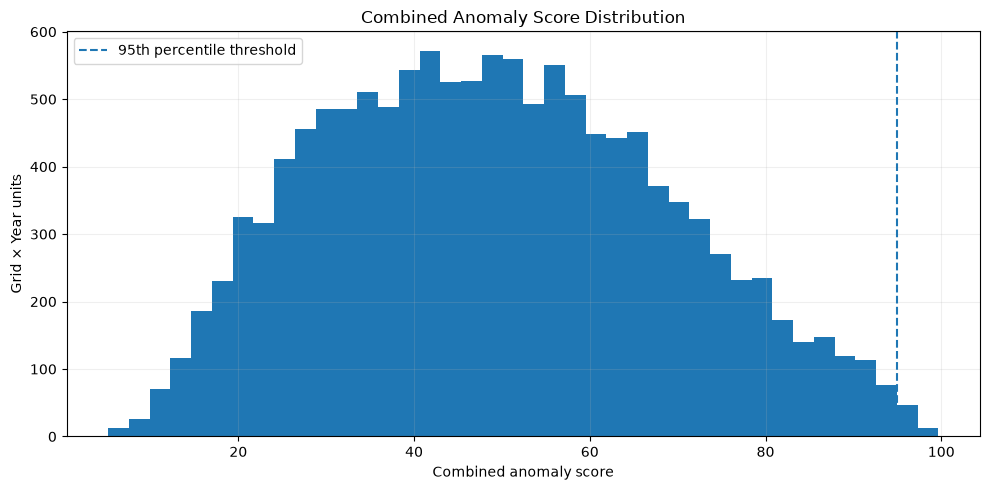

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    eligible["combined_anomaly_score"].dropna(),
    bins=40,
)

ax.axvline(
    ANOMALY_PERCENTILE_THRESHOLD,
    linestyle="--",
    label="95th percentile threshold",
)

ax.set_title("Combined Anomaly Score Distribution")
ax.set_xlabel("Combined anomaly score")
ax.set_ylabel("Grid × Year units")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


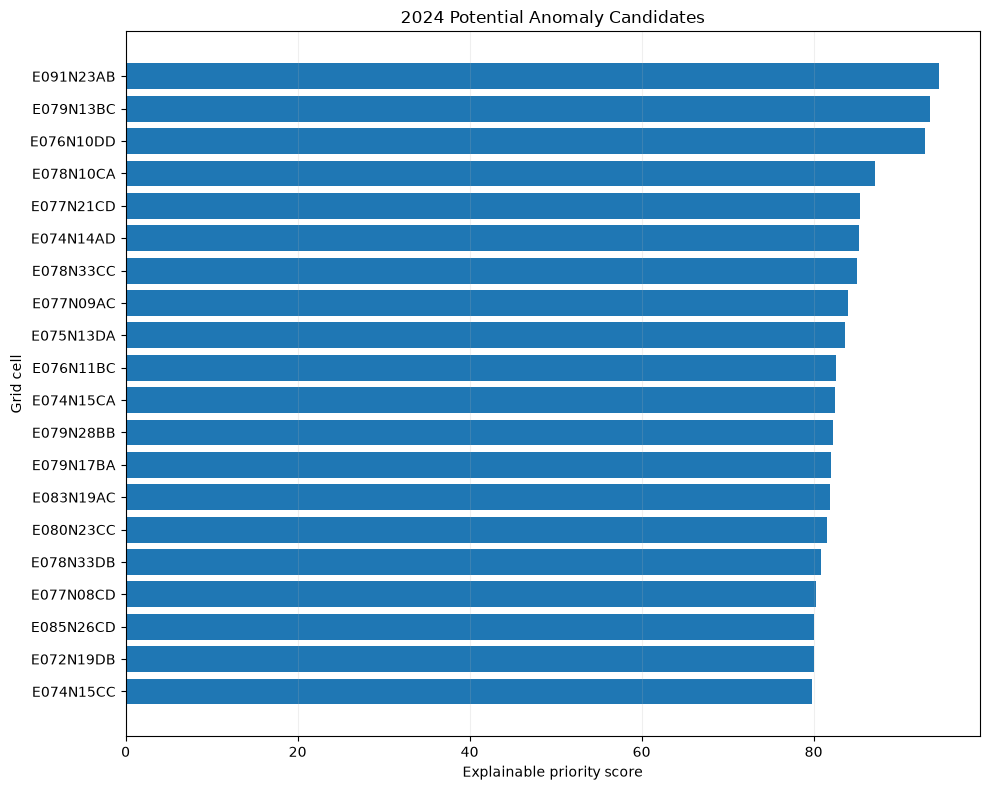

In [20]:
plot_2024 = anomalies_2024.head(20).sort_values(
    "priority_score"
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    plot_2024["eqdcellcode"].astype(str),
    plot_2024["priority_score"],
)

ax.set_title("2024 Potential Anomaly Candidates")
ax.set_xlabel("Explainable priority score")
ax.set_ylabel("Grid cell")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


## 15. Approximate spatial visualization

The GBIF cube stores the EQDGC cell code rather than the original coordinates in this processed dataset.

The decoder below computes an approximate cell centre for visualization. It is **not** used to reconstruct occurrence coordinates or calculate new geographic uncertainty.


In [21]:
import re

def decode_qdgc_center(code):
    m = re.fullmatch(
        r"([EW])(\d{3})([NS])(\d{2})([A-D]{2})",
        str(code),
    )

    if not m:
        return (np.nan, np.nan)

    ew, lon_deg, ns, lat_deg, suffix = m.groups()

    lon_deg = float(lon_deg)
    lat_deg = float(lat_deg)

    if ew == "E":
        lon_min, lon_max = lon_deg, lon_deg + 1
    else:
        lon_min, lon_max = -lon_deg - 1, -lon_deg

    if ns == "N":
        lat_min, lat_max = lat_deg, lat_deg + 1
    else:
        lat_min, lat_max = -lat_deg - 1, -lat_deg

    for letter in suffix:
        lon_mid = (lon_min + lon_max) / 2
        lat_mid = (lat_min + lat_max) / 2

        if letter == "A":       # NW
            lon_max, lat_min = lon_mid, lat_mid
        elif letter == "B":     # NE
            lon_min, lat_min = lon_mid, lat_mid
        elif letter == "C":     # SW
            lon_max, lat_max = lon_mid, lat_mid
        elif letter == "D":     # SE
            lon_min, lat_max = lon_mid, lat_mid

    return (
        (lon_min + lon_max) / 2,
        (lat_min + lat_max) / 2,
    )


spatial_2024 = anomalies_2024.copy()

centres = spatial_2024["eqdcellcode"].map(
    decode_qdgc_center
)

spatial_2024["longitude"] = centres.map(lambda x: x[0])
spatial_2024["latitude"] = centres.map(lambda x: x[1])

spatial_2024 = spatial_2024.dropna(
    subset=["longitude", "latitude"]
)

print(
    "2024 anomaly candidates with decodable grid centres:",
    len(spatial_2024)
)


2024 anomaly candidates with decodable grid centres: 246


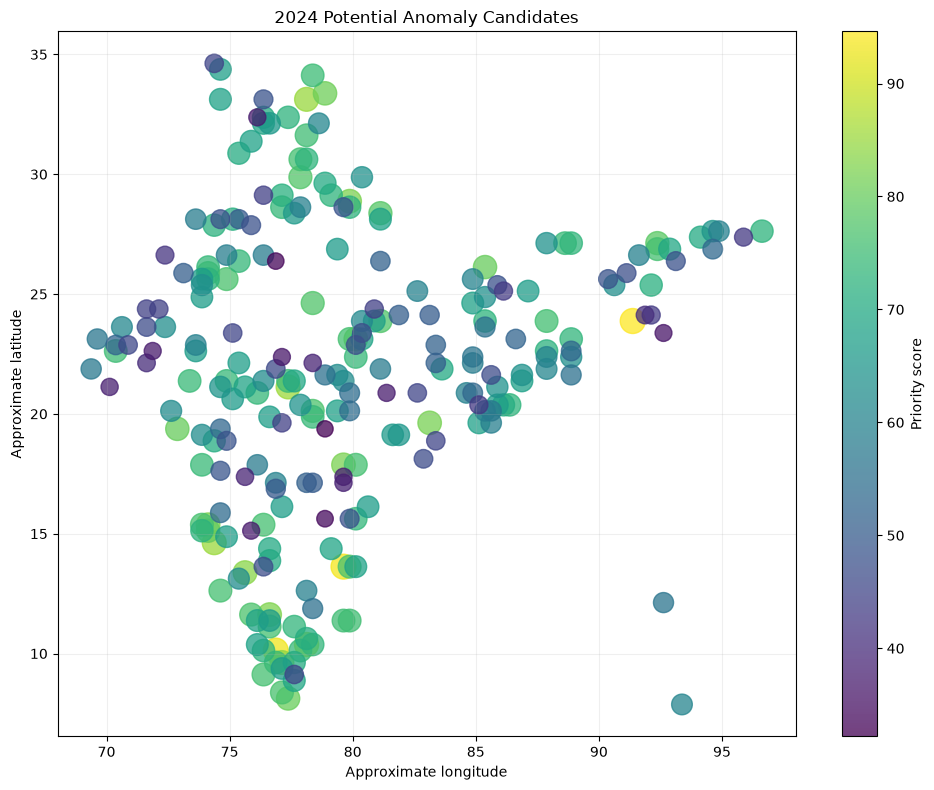

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

if len(spatial_2024) > 0:
    scatter = ax.scatter(
        spatial_2024["longitude"],
        spatial_2024["latitude"],
        s=40 + 3 * spatial_2024["priority_score"],
        c=spatial_2024["priority_score"],
        alpha=0.75,
    )

    fig.colorbar(
        scatter,
        ax=ax,
        label="Priority score",
    )

ax.set_title("2024 Potential Anomaly Candidates")
ax.set_xlabel("Approximate longitude")
ax.set_ylabel("Approximate latitude")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 16. Export anomaly-intelligence outputs

In [23]:
ANOMALY_OUTPUT_PATH = (
    OUTPUT_DIR
    / "biosentinel_anomaly_intelligence.parquet"
)

ANOMALY_2024_PATH = (
    OUTPUT_DIR
    / "biosentinel_2024_anomaly_candidates.csv"
)

SENSITIVITY_PATH = (
    OUTPUT_DIR
    / "biosentinel_anomaly_sensitivity.csv"
)

SUMMARY_PATH = (
    OUTPUT_DIR
    / "biosentinel_anomaly_model_summary.json"
)

all_results.to_parquet(
    ANOMALY_OUTPUT_PATH,
    index=False,
)

anomalies_2024.to_csv(
    ANOMALY_2024_PATH,
    index=False,
)

sensitivity_df.to_csv(
    SENSITIVITY_PATH,
    index=False,
)

model_summary = {
    "analysis_start_year": ANALYSIS_START_YEAR,
    "analysis_end_year": ANALYSIS_END_YEAR,
    "model_train_end_year": MODEL_TRAIN_END_YEAR,
    "eligible_grid_year_units": int(len(eligible)),
    "eligible_grid_cells": int(
        eligible["eqdcellcode"].nunique()
    ),
    "preliminary_anomaly_candidates": int(
        eligible["preliminary_anomaly_flag"].sum()
    ),
    "potential_2024_candidates": int(
        len(anomalies_2024)
    ),
    "robust_deviation_threshold": ROBUST_DEVIATION_THRESHOLD,
    "anomaly_percentile_threshold": ANOMALY_PERCENTILE_THRESHOLD,
    "isolation_forest_contamination": IF_CONTAMINATION,
    "isolation_forest_random_state": IF_RANDOM_STATE,
    "spatial_effort_spearman_correlation": float(
        eligible[
            [
                "combined_anomaly_score",
                "log_observation_effort",
            ]
        ].corr(method="spearman").iloc[0, 1]
    ),
}

SUMMARY_PATH.write_text(
    json.dumps(model_summary, indent=2),
    encoding="utf-8",
)

print("Created:")
print("-", ANOMALY_OUTPUT_PATH)
print("-", ANOMALY_2024_PATH)
print("-", SENSITIVITY_PATH)
print("-", SUMMARY_PATH)


Created:
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_anomaly_intelligence.parquet
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_2024_anomaly_candidates.csv
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_anomaly_sensitivity.csv
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_anomaly_model_summary.json


# Part B — EfficientNet Species Identification

The image model is deliberately isolated from the GBIF anomaly pipeline.

### Expected local directory structure

```text
data/
└── raw/
    └── inaturalist/
        └── images/
            ├── Species_A/
            │   ├── image001.jpg
            │   └── ...
            ├── Species_B/
            │   └── ...
            └── ...
```

Classes with fewer than `MIN_IMAGES_PER_CLASS` images are excluded from the first training experiment.

**No synthetic fallback dataset is used.** If the image dataset is not present, the notebook stops this image branch with a clear message.


## 17. Image-dataset configuration

In [24]:

import torch
# Image experiment configuration
#
# IMPORTANT:
# The finalized BioSentinel image dataset was already split at GBIF
# occurrence level before download. Do NOT perform another random split.

IMAGE_SIZE = 224

# RTX 4050 6 GB: start at 32. Reduce to 24 if VRAM is exhausted.
BATCH_SIZE = 32

# Windows/Jupyter: 4 workers is a reasonable starting point.
NUM_WORKERS = 0
PREFETCH_FACTOR = 2

# Final prepared dataset policy.
EXPECTED_SPECIES = 1106
EXPECTED_IMAGES = 33180
EXPECTED_TRAIN_IMAGES = 23226
EXPECTED_VAL_IMAGES = 4426
EXPECTED_TEST_IMAGES = 5528

WARMUP_EPOCHS = 2
FINETUNE_EPOCHS = 5

LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINETUNE = 1e-4
WEIGHT_DECAY = 1e-4

TORCH_SEED = 42

# Mixed precision is strongly recommended on the RTX 4050.
USE_AMP = True

# Faster kernels for fixed 224x224 input.
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print("Final manifest:", IMAGE_MANIFEST_PATH)
print("Image root:", IMAGE_ROOT)
print("Batch size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)
print("AMP:", USE_AMP)


Final manifest: d:\Biosential_India\data\processed\inaturalist\efficientnet_30_reuse_manifest.csv
Image root: d:\Biosential_India\data\raw\inaturalist\images
Batch size: 32
Workers: 0
AMP: True


In [25]:

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(
        f"Image dataset not found at:\n{IMAGE_ROOT}"
    )

if not IMAGE_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Final EfficientNet manifest not found at:\n{IMAGE_MANIFEST_PATH}\n"
        "Expected efficientnet_30_reuse_manifest.csv."
    )

print("Image root exists:", IMAGE_ROOT.exists())
print("Final manifest exists:", IMAGE_MANIFEST_PATH.exists())


Image root exists: True
Final manifest exists: True


## 18. Load the finalized BioSentinel image manifest

The EfficientNet experiment uses `efficientnet_30_reuse_manifest.csv` as its single source of truth.

The dataset was already split at GBIF-occurrence level:
- 1,106 species
- 30 images per species
- 21 train / 4 validation / 5 test
- no GBIF occurrence may cross splits

This section does **not** use `ImageFolder(IMAGE_ROOT)` and does **not** perform another random split.


In [26]:

from pathlib import Path
import sys
import hashlib
from collections import Counter

print("Python:", sys.version)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    print("torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("CUDA version:", torch.version.cuda)
        print("GPU:", torch.cuda.get_device_name(0))

except Exception as exc:
    raise RuntimeError(
        f"PyTorch import failed: {type(exc).__name__}: {exc}"
    ) from exc

try:
    import torchvision
    from torchvision import transforms
    from torchvision.models import (
        efficientnet_b0,
        EfficientNet_B0_Weights,
    )
    print("torchvision:", torchvision.__version__)

except Exception as exc:
    raise RuntimeError(
        f"torchvision import failed: {type(exc).__name__}: {exc}"
    ) from exc

try:
    from PIL import Image
except Exception as exc:
    raise RuntimeError(
        f"Pillow import failed: {type(exc).__name__}: {exc}"
    ) from exc

if not IMAGE_MANIFEST_PATH.exists():
    raise FileNotFoundError(IMAGE_MANIFEST_PATH)

final_manifest = pd.read_csv(
    IMAGE_MANIFEST_PATH,
    low_memory=False,
)

required_columns = {
    "gbifID",
    "species",
    "speciesKey",
    "species_folder",
    "split",
    "image_url",
}

missing = required_columns - set(final_manifest.columns)

if missing:
    raise ValueError(
        f"Final manifest is missing columns: {sorted(missing)}"
    )

final_manifest["gbifID"] = (
    final_manifest["gbifID"]
    .astype("string")
    .str.strip()
)

final_manifest["speciesKey"] = (
    final_manifest["speciesKey"]
    .astype("string")
    .str.strip()
)

final_manifest["split"] = (
    final_manifest["split"]
    .astype("string")
    .str.strip()
)

print("\nFINAL MANIFEST AUDIT")
print("--------------------")
print("Rows:", f"{len(final_manifest):,}")
print(
    "Species:",
    f"{final_manifest['speciesKey'].nunique():,}"
)
print(
    "Occurrences:",
    f"{final_manifest['gbifID'].nunique():,}"
)

print("\nSplit counts:")
print(
    final_manifest["split"]
    .value_counts()
    .reindex(["train", "val", "test"])
    .fillna(0)
    .astype(int)
    .to_string()
)

per_species = (
    final_manifest
    .groupby("speciesKey")
    .size()
)

print(
    "\nImages/species:",
    f"min={per_species.min()}, "
    f"median={per_species.median():.0f}, "
    f"max={per_species.max()}"
)

if len(final_manifest) != EXPECTED_IMAGES:
    raise ValueError(
        f"Expected {EXPECTED_IMAGES:,} manifest rows, "
        f"found {len(final_manifest):,}."
    )

if final_manifest["speciesKey"].nunique() != EXPECTED_SPECIES:
    raise ValueError(
        f"Expected {EXPECTED_SPECIES:,} species, "
        f"found {final_manifest['speciesKey'].nunique():,}."
    )

if per_species.min() != 30 or per_species.max() != 30:
    raise ValueError(
        "Final manifest must contain exactly 30 images/species."
    )

# Occurrence-level leakage check.
occurrence_split_counts = (
    final_manifest
    .groupby("gbifID")["split"]
    .nunique()
)

if (occurrence_split_counts > 1).any():
    raise RuntimeError(
        "GBIF occurrence leakage detected: an occurrence appears "
        "in more than one split."
    )

print("\nManifest validation: PASSED")


Python: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
torch: 2.14.0+cu130
CUDA available: True
CUDA version: 13.0
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
torchvision: 0.29.0+cu130

FINAL MANIFEST AUDIT
--------------------
Rows: 33,180
Species: 1,106
Occurrences: 27,619

Split counts:
split
train    23226
val       4426
test      5528

Images/species: min=30, median=30, max=30

Manifest validation: PASSED


## 19. Resolve exact local image paths and validate the final split

Each manifest row is mapped back to the deterministic filename produced by the downloader.

Before training, the notebook verifies:
- all 33,180 selected files exist
- exactly 1,106 species are present
- exactly 30 images/species are present
- no GBIF occurrence appears in multiple splits


In [27]:

# Build the exact local image path used by the downloader.
def local_image_filename(row):
    gbif_id = str(row["gbifID"]).strip()
    url = str(row["image_url"]).strip()

    url_hash = hashlib.sha1(
        url.encode("utf-8")
    ).hexdigest()[:12]

    media_format = str(
        row.get("media_format", "")
    ).strip().lower()

    if media_format in {"image/jpeg", "image/pjpeg"}:
        ext = ".jpg"
    elif media_format == "image/png":
        ext = ".png"
    elif media_format == "image/gif":
        ext = ".gif"
    elif media_format == "image/webp":
        ext = ".webp"
    else:
        ext = ".jpg"

    return f"{gbif_id}__{url_hash}{ext}"


final_manifest["local_path"] = final_manifest.apply(
    lambda row: str(
        IMAGE_ROOT
        / str(row["split"])
        / str(row["species_folder"])
        / local_image_filename(row)
    ),
    axis=1,
)

# Verify every selected image exists before constructing DataLoaders.
missing_files = [
    path
    for path in final_manifest["local_path"]
    if not Path(path).exists()
]

print(
    "Manifest images missing on disk:",
    f"{len(missing_files):,}"
)

if missing_files:
    print("\nFirst missing paths:")
    for path in missing_files[:10]:
        print(path)

    raise FileNotFoundError(
        f"{len(missing_files):,} selected manifest images are missing."
    )

# Deterministic class mapping by speciesKey.
class_table = (
    final_manifest[
        ["speciesKey", "species"]
    ]
    .drop_duplicates()
    .sort_values(
        ["speciesKey", "species"]
    )
    .reset_index(drop=True)
)

ordered_species_keys = (
    class_table["speciesKey"]
    .astype(str)
    .tolist()
)

ordered_class_names = (
    class_table["species"]
    .astype(str)
    .tolist()
)

label_map = {
    species_key: index
    for index, species_key in enumerate(
        ordered_species_keys
    )
}

final_manifest["label"] = (
    final_manifest["speciesKey"]
    .astype(str)
    .map(label_map)
)

if final_manifest["label"].isna().any():
    raise RuntimeError(
        "Some manifest rows could not be mapped to a class."
    )

final_manifest["label"] = (
    final_manifest["label"]
    .astype(int)
)

print("\nExact dataset used for training:")
print("Classes:", len(ordered_class_names))
print("Images:", len(final_manifest))
print(
    "Train:",
    int((final_manifest["split"] == "train").sum())
)
print(
    "Val:",
    int((final_manifest["split"] == "val").sum())
)
print(
    "Test:",
    int((final_manifest["split"] == "test").sum())
)

# Save a copy documenting the exact model input.
MODEL_MANIFEST_PATH = (
    OUTPUT_DIR
    / "efficientnet_final_input_manifest.csv"
)

final_manifest.to_csv(
    MODEL_MANIFEST_PATH,
    index=False,
)

print(
    "Model input manifest:",
    MODEL_MANIFEST_PATH
)


Manifest images missing on disk: 0

Exact dataset used for training:
Classes: 1106
Images: 33180
Train: 23226
Val: 4426
Test: 5528
Model input manifest: d:\Biosential_India\data\processed\analytics\person3\efficientnet_final_input_manifest.csv


## 20. Image transforms and optimized data loaders

Training uses moderate augmentation.

The data loader is tuned for the local RTX 4050 setup:
- batch size 32
- four workers
- pinned memory
- persistent workers
- prefetching
- non-blocking CUDA transfers
- channels-last tensors


In [28]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.70, 1.0),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.05,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        int(IMAGE_SIZE * 1.14)
    ),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])


class SpeciesImageDataset(Dataset):
    def __init__(
        self,
        frame,
        transform=None,
    ):
        self.frame = (
            frame
            .reset_index(drop=True)
            .copy()
        )
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        path = row["local_path"]

        with Image.open(path) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["label"])

        return image, label


train_frame = final_manifest[
    final_manifest["split"] == "train"
].copy()

val_frame = final_manifest[
    final_manifest["split"] == "val"
].copy()

test_frame = final_manifest[
    final_manifest["split"] == "test"
].copy()

train_dataset = SpeciesImageDataset(
    train_frame,
    train_transform,
)

val_dataset = SpeciesImageDataset(
    val_frame,
    eval_transform,
)

test_dataset = SpeciesImageDataset(
    test_frame,
    eval_transform,
)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

print("Data loaders ready.")
print(
    f"Train batches: {len(train_loader):,}"
)
print(
    f"Val batches:   {len(val_loader):,}"
)
print(
    f"Test batches:  {len(test_loader):,}"
)


Data loaders ready.
Train batches: 726
Val batches:   139
Test batches:  173


## 21. Build EfficientNet-B0 transfer-learning model

EfficientNet-B0 is initialized from pretrained weights and its classifier is replaced with 1,106 species outputs.

The warm-up phase freezes the feature extractor. The RTX 4050 uses CUDA mixed precision (AMP) to reduce memory traffic and improve throughput.


In [29]:

torch.manual_seed(TORCH_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TORCH_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)

    print("Device:", device)
    print("GPU:", gpu_name)
    print(
        "VRAM:",
        f"{torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB"
    )
else:
    print("Device:", device)

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

num_classes = len(ordered_class_names)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    num_classes,
)

# Warm-up: freeze the feature extractor.
for parameter in model.features.parameters():
    parameter.requires_grad = False

# Channels-last can improve convolution throughput on CUDA.
model = model.to(device)

if device.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

class_counts_train = np.bincount(
    train_frame["label"].to_numpy(),
    minlength=num_classes,
).astype(float)

class_weights = (
    class_counts_train.sum()
    / np.maximum(class_counts_train, 1)
)

class_weights = (
    class_weights
    / class_weights.mean()
)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device,
    )
)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY,
)

amp_enabled = (
    USE_AMP
    and device.type == "cuda"
)

amp_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=amp_enabled,
)

print("Number of classes:", num_classes)
print("AMP enabled:", amp_enabled)

if device.type == "cuda":
    print(
        "Initial allocated VRAM:",
        f"{torch.cuda.memory_allocated() / (1024**2):.0f} MB"
    )
    print(
        "Initial reserved VRAM:",
        f"{torch.cuda.memory_reserved() / (1024**2):.0f} MB"
    )


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.00 GB
Number of classes: 1106
AMP enabled: True
Initial allocated VRAM: 21 MB
Initial reserved VRAM: 36 MB


## 22. Training utilities

Training reports progress every 50 batches so a long epoch does not appear stalled.

Metrics:
- loss
- top-1 accuracy
- top-5 accuracy
- macro precision
- macro recall
- macro F1


In [30]:

def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
    phase_name="train",
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    total = 0
    correct = 0
    top5_correct = 0

    all_targets = []
    all_predictions = []

    total_batches = len(loader)

    for batch_index, (images, labels) in enumerate(
        loader,
        start=1,
    ):
        if device.type == "cuda":
            images = images.to(
                device,
                non_blocking=True,
            ).to(
                memory_format=torch.channels_last
            )
        else:
            images = images.to(
                device,
                non_blocking=True,
            )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        if is_training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(is_training):
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                outputs = model(images)
                loss = criterion(
                    outputs,
                    labels,
                )

            if is_training:
                if scaler is not None and amp_enabled:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        total += batch_size

        predictions = outputs.argmax(
            dim=1
        )

        correct += int(
            (predictions == labels)
            .sum()
            .item()
        )

        k = min(
            5,
            outputs.shape[1],
        )

        top5_predictions = outputs.topk(
            k=k,
            dim=1,
        ).indices

        top5_correct += int(
            (
                top5_predictions
                == labels.unsqueeze(1)
            )
            .any(dim=1)
            .sum()
            .item()
        )

        all_targets.extend(
            labels.detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
            .tolist()
        )

        # Visible progress so a long epoch doesn't look frozen.
        if (
            batch_index == 1
            or batch_index % 50 == 0
            or batch_index == total_batches
        ):
            progress_pct = (
                batch_index
                / total_batches
                * 100
            )

            current_loss = (
                running_loss / total
            )

            current_acc = (
                correct / total
            )

            print(
                f"\r{phase_name}: "
                f"{batch_index:,}/{total_batches:,} "
                f"({progress_pct:5.1f}%) | "
                f"loss={current_loss:.4f} | "
                f"acc={current_acc:.4f}",
                end="",
                flush=True,
            )

    print()

    avg_loss = (
        running_loss
        / max(total, 1)
    )

    accuracy = correct / max(total, 1)

    top5_accuracy = (
        top5_correct
        / max(total, 1)
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0,
        )
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "top5_accuracy": top5_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "targets": np.array(
            all_targets
        ),
        "predictions": np.array(
            all_predictions
        ),
    }


def save_checkpoint(
    path,
    epoch,
    model,
    class_names,
    class_keys,
    metrics,
):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "species_keys": class_keys,
            "metrics": metrics,
        },
        path,
    )


history = []
best_val_f1 = -np.inf

print("Training utilities ready.")


Training utilities ready.


## 23. EfficientNet warm-up training

Two head-only epochs are run.

The notebook prints batch-level progress and saves the best checkpoint using validation macro F1.


In [31]:
import time
import torch

print("CUDA:", torch.cuda.is_available())
print("Device:", device)

# ------------------------------------------------------------
# 1. Test CUDA itself
# ------------------------------------------------------------
print("\n[1] CUDA compute test...")

x = torch.randn(
    2048,
    2048,
    device="cuda",
)

torch.cuda.synchronize()

start = time.perf_counter()

for _ in range(20):
    y = x @ x

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

print(
    f"CUDA matmul test: {elapsed:.3f}s"
)

del x, y
torch.cuda.empty_cache()


# ------------------------------------------------------------
# 2. Test the DataLoader WITHOUT worker processes
# ------------------------------------------------------------
print("\n[2] DataLoader test...")

diagnostic_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

start = time.perf_counter()

images, labels = next(iter(diagnostic_loader))

elapsed = time.perf_counter() - start

print(
    f"First batch loaded in {elapsed:.2f}s"
)

print(
    "Batch shape:",
    images.shape,
)

print(
    "Labels shape:",
    labels.shape,
)


# ------------------------------------------------------------
# 3. Test EfficientNet forward pass
# ------------------------------------------------------------
print("\n[3] EfficientNet GPU forward test...")

model.eval()

images = images.to(
    device,
    non_blocking=True,
)

if device.type == "cuda":
    images = images.to(
        memory_format=torch.channels_last
    )

torch.cuda.synchronize()

start = time.perf_counter()

with torch.no_grad():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=True,
    ):
        outputs = model(images)

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

print(
    f"Forward pass: {elapsed:.3f}s"
)

print(
    "Output shape:",
    outputs.shape,
)

print(
    "GPU allocated:",
    f"{torch.cuda.memory_allocated() / 1024**2:.0f} MB"
)

print(
    "GPU reserved:",
    f"{torch.cuda.memory_reserved() / 1024**2:.0f} MB"
)

print("\nDIAGNOSTIC COMPLETE")

CUDA: True
Device: cuda

[1] CUDA compute test...
CUDA matmul test: 0.161s

[2] DataLoader test...
First batch loaded in 1.10s
Batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])

[3] EfficientNet GPU forward test...
Forward pass: 4.578s
Output shape: torch.Size([16, 1106])
GPU allocated: 39 MB
GPU reserved: 56 MB

DIAGNOSTIC COMPLETE


In [32]:
import time
import torch

print("Model device:", next(model.parameters()).device)
print("CUDA device:", torch.cuda.get_device_name(0))

# Get one batch
images, labels = next(iter(diagnostic_loader))
images = images.to(device, non_blocking=True)

if device.type == "cuda":
    images = images.contiguous(memory_format=torch.channels_last)

model.eval()

# Warm-up passes — absorbs CUDA/cuDNN initialization
with torch.no_grad():
    for _ in range(3):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            _ = model(images)

if device.type == "cuda":
    torch.cuda.synchronize()

# Timed passes
times = []

with torch.no_grad():
    for i in range(10):
        start = time.perf_counter()

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start
        times.append(elapsed)
        print(f"Pass {i+1:02d}: {elapsed:.4f}s")

print("\nAverage:", sum(times) / len(times))
print("Min:", min(times))
print("Images/sec:", 16 / (sum(times) / len(times)))
print(
    "GPU allocated:",
    round(torch.cuda.memory_allocated() / 1024**2, 1),
    "MB"
)
print(
    "GPU reserved:",
    round(torch.cuda.memory_reserved() / 1024**2, 1),
    "MB"
)

Model device: cuda:0
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU
Pass 01: 0.0138s
Pass 02: 0.0243s
Pass 03: 0.0234s
Pass 04: 0.0128s
Pass 05: 0.0122s
Pass 06: 0.0169s
Pass 07: 0.0131s
Pass 08: 0.0120s
Pass 09: 0.0113s
Pass 10: 0.0109s

Average: 0.01507417999999916
Min: 0.0108592999999928
Images/sec: 1061.4176028149386
GPU allocated: 38.9 MB
GPU reserved: 192.0 MB


In [33]:

for epoch in range(
    1,
    WARMUP_EPOCHS + 1,
):

    print(
        f"\n=== WARM-UP EPOCH {epoch}/{WARMUP_EPOCHS} ==="
    )

    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        amp_scaler,
        phase_name=f"warmup train {epoch}",
    )

    val_metrics = run_epoch(
        model,
        val_loader,
        criterion,
        phase_name=f"warmup val {epoch}",
    )

    history.append({
        "epoch": epoch,
        "phase": "warmup",
        **{
            f"train_{k}": v
            for k, v in train_metrics.items()
            if k not in {
                "targets",
                "predictions",
            }
        },
        **{
            f"val_{k}": v
            for k, v in val_metrics.items()
            if k not in {
                "targets",
                "predictions",
            }
        },
    })

    print(
        f"Warm-up epoch {epoch}/{WARMUP_EPOCHS} | "
        f"train F1={train_metrics['macro_f1']:.4f} | "
        f"val F1={val_metrics['macro_f1']:.4f} | "
        f"val top-5={val_metrics['top5_accuracy']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]

        save_checkpoint(
            MODEL_DIR
            / "efficientnet_b0_biosentinel_best.pth",
            epoch,
            model,
            ordered_class_names,
            ordered_species_keys,
            val_metrics,
        )



=== WARM-UP EPOCH 1/2 ===
warmup train 1: 1/726 (  0.1%) | loss=7.0101 | acc=0.0000

KeyboardInterrupt: 

## 24. EfficientNet fine-tuning

The full EfficientNet backbone is unfrozen for five fine-tuning epochs.

The test set remains untouched during model selection.


In [ ]:

# Unfreeze the full backbone for fine-tuning.
for parameter in model.features.parameters():
    parameter.requires_grad = True

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE_FINETUNE,
    weight_decay=WEIGHT_DECAY,
)

amp_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=amp_enabled,
)

start_epoch = WARMUP_EPOCHS

for offset in range(
    1,
    FINETUNE_EPOCHS + 1,
):

    epoch = start_epoch + offset

    print(
        f"\n=== FINE-TUNE EPOCH "
        f"{offset}/{FINETUNE_EPOCHS} "
        f"(global {epoch}) ==="
    )

    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        amp_scaler,
        phase_name=f"finetune train {offset}",
    )

    val_metrics = run_epoch(
        model,
        val_loader,
        criterion,
        phase_name=f"finetune val {offset}",
    )

    history.append({
        "epoch": epoch,
        "phase": "finetune",
        **{
            f"train_{k}": v
            for k, v in train_metrics.items()
            if k not in {
                "targets",
                "predictions",
            }
        },
        **{
            f"val_{k}": v
            for k, v in val_metrics.items()
            if k not in {
                "targets",
                "predictions",
            }
        },
    })

    print(
        f"Fine-tune epoch {offset}/{FINETUNE_EPOCHS} | "
        f"train F1={train_metrics['macro_f1']:.4f} | "
        f"val F1={val_metrics['macro_f1']:.4f} | "
        f"val top-5={val_metrics['top5_accuracy']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]

        save_checkpoint(
            MODEL_DIR
            / "efficientnet_b0_biosentinel_best.pth",
            epoch,
            model,
            ordered_class_names,
            ordered_species_keys,
            val_metrics,
        )



=== FINE-TUNE EPOCH 1/5 (global 3) ===
finetune train 1: 726/726 (100.0%) | loss=2.2344 | acc=0.5427
finetune val 1: 139/139 (100.0%) | loss=3.0518 | acc=0.3572
Fine-tune epoch 1/5 | train F1=0.5342 | val F1=0.3327 | val top-5=0.6071

=== FINE-TUNE EPOCH 2/5 (global 4) ===
finetune train 2: 726/726 (100.0%) | loss=1.6542 | acc=0.6459
finetune val 2: 139/139 (100.0%) | loss=2.8649 | acc=0.3821
Fine-tune epoch 2/5 | train F1=0.6422 | val F1=0.3602 | val top-5=0.6435

=== FINE-TUNE EPOCH 3/5 (global 5) ===
finetune train 3: 726/726 (100.0%) | loss=1.3455 | acc=0.7124
finetune val 3: 139/139 (100.0%) | loss=2.7780 | acc=0.4028
Fine-tune epoch 3/5 | train F1=0.7102 | val F1=0.3830 | val top-5=0.6584

=== FINE-TUNE EPOCH 4/5 (global 6) ===
finetune train 4: 726/726 (100.0%) | loss=1.0957 | acc=0.7657
finetune val 4: 139/139 (100.0%) | loss=2.7440 | acc=0.4141
Fine-tune epoch 4/5 | train F1=0.7646 | val F1=0.3976 | val top-5=0.6704

=== FINE-TUNE EPOCH 5/5 (global 7) ===
finetune train 5: 72

## 25. Plot training history

KeyError: 'epoch'

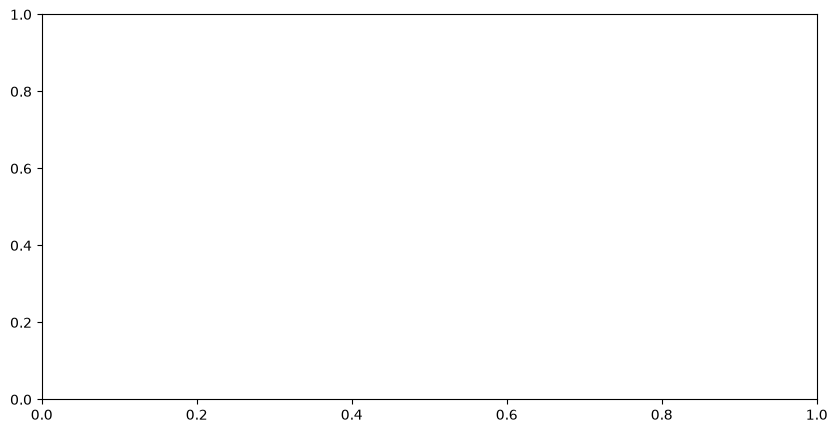

In [34]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    marker="o",
    label="Train macro F1",
)

ax.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o",
    label="Validation macro F1",
)

ax.set_title("EfficientNet-B0 Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 26. Final test-set evaluation

In [35]:
best_checkpoint = MODEL_DIR / "efficientnet_b0_biosentinel_best.pth"

if best_checkpoint.exists():
    checkpoint = torch.load(
        best_checkpoint,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        "Loaded best checkpoint from epoch:",
        checkpoint["epoch"]
    )

test_metrics = run_epoch(
    model,
    test_loader,
    criterion,
)

targets = test_metrics["targets"]
predictions = test_metrics["predictions"]

print(
    "Test accuracy:",
    f"{test_metrics['accuracy']:.4f}"
)

print(
    "Test macro precision:",
    f"{test_metrics['macro_precision']:.4f}"
)

print(
    "Test macro recall:",
    f"{test_metrics['macro_recall']:.4f}"
)

print(
    "Test macro F1:",
    f"{test_metrics['macro_f1']:.4f}"
)

print("\nClassification report:")

print(
    classification_report(
        targets,
        predictions,
        target_names=ordered_class_names,
        zero_division=0,
    )
)

Loaded best checkpoint from epoch: 7
train: 173/173 (100.0%) | loss=2.6790 | acc=0.4260
Test accuracy: 0.4260
Test macro precision: 0.4384
Test macro recall: 0.4259
Test macro F1: 0.4108

Classification report:
                                precision    recall  f1-score   support

        Cucumis maderaspatanus       0.43      0.60      0.50         5
              Cupha erymanthis       0.75      0.60      0.67         5
          Curculigo orchioides       1.00      1.00      1.00         5
                Curetis thetis       1.00      0.60      0.75         5
            Cyanotis axillaris       0.22      0.40      0.29         5
             Cyanotis cristata       0.67      0.40      0.50         5
          Cyanotis fasciculata       0.25      0.20      0.22         5
         Cyanthillium cinereum       0.50      0.40      0.44         5
            Cyornis poliogenys       0.20      0.20      0.20         5
          Cyornis rubeculoides       0.07      0.20      0.11       

Confusion matrix shape: (1106, 1106)


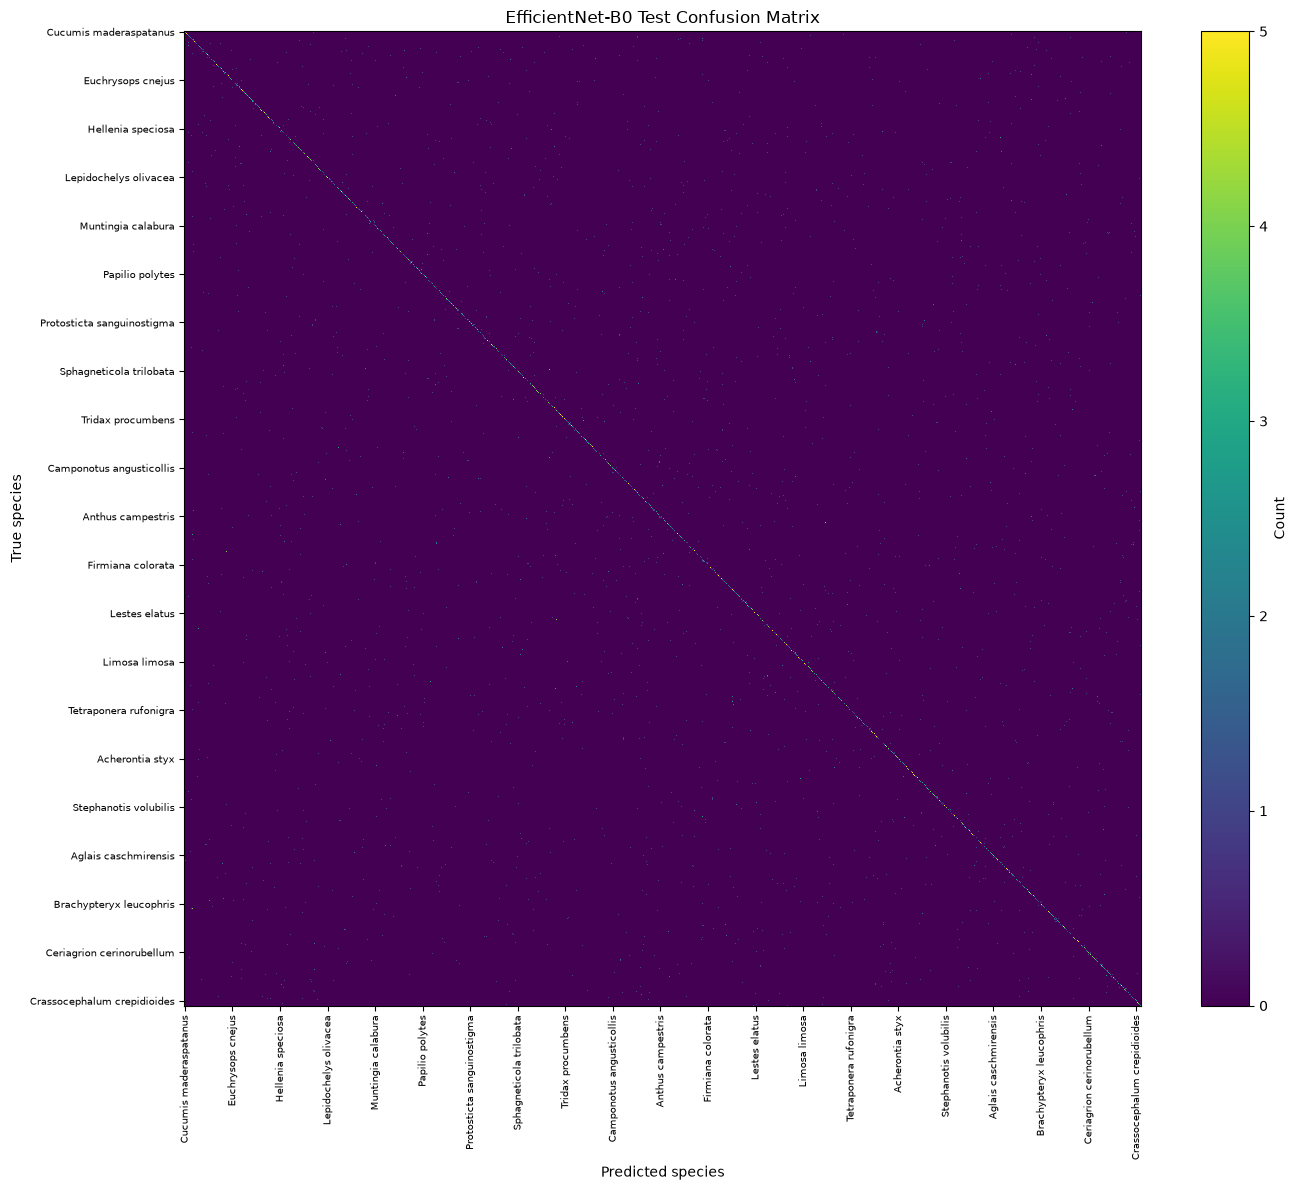

In [36]:
from sklearn.metrics import confusion_matrix

# Recover test predictions if they are not already in memory
if "targets" not in globals() or "predictions" not in globals():
    print("Test predictions not found. Running test evaluation...")
    
    test_metrics = run_epoch(
        model,
        test_loader,
        criterion,
    )
    
    targets = test_metrics["targets"]
    predictions = test_metrics["predictions"]

# Build confusion matrix
cm = confusion_matrix(
    targets,
    predictions,
)

print("Confusion matrix shape:", cm.shape)

# Fixed-size figure: avoids the huge-memory allocation
fig, ax = plt.subplots(
    figsize=(14, 12),
    dpi=100,
)

image = ax.imshow(
    cm,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title("EfficientNet-B0 Test Confusion Matrix")
ax.set_xlabel("Predicted species")
ax.set_ylabel("True species")

# 1,106 labels cannot be displayed legibly, so show ~20 labels
tick_step = max(1, num_classes // 20)
tick_positions = np.arange(0, num_classes, tick_step)

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

ax.set_xticklabels(
    [ordered_class_names[i] for i in tick_positions],
    rotation=90,
    fontsize=7,
)

ax.set_yticklabels(
    [ordered_class_names[i] for i in tick_positions],
    fontsize=7,
)

fig.colorbar(
    image,
    ax=ax,
    label="Count",
)

plt.tight_layout()
plt.show()
plt.close(fig)

## 27. Export EfficientNet evaluation results

In [38]:
MODEL_METRICS_PATH = (
    OUTPUT_DIR
    / "efficientnet_b0_test_metrics.json"
)

HISTORY_PATH = (
    OUTPUT_DIR
    / "efficientnet_b0_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)

image_metrics = {
    "device": str(device),
    "num_classes": int(num_classes),
    "classes": ordered_class_names,
    "train_images": int(len(train_dataset)),
    "validation_images": int(len(val_dataset)),
    "test_images": int(len(test_dataset)),

    # Final dataset policy: 100 images/species minimum
    "min_images_per_class": 100,

    "warmup_epochs": int(WARMUP_EPOCHS),
    "finetune_epochs": int(FINETUNE_EPOCHS),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_macro_precision": float(test_metrics["macro_precision"]),
    "test_macro_recall": float(test_metrics["macro_recall"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
}

MODEL_METRICS_PATH.write_text(
    json.dumps(
        image_metrics,
        indent=2,
    ),
    encoding="utf-8",
)

FINAL_MODEL_PATH = (
    MODEL_DIR
    / "efficientnet_b0_biosentinel_final.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": ordered_class_names,
        "image_size": IMAGE_SIZE,
        "test_metrics": image_metrics,
    },
    FINAL_MODEL_PATH,
)

print("Created:")
print("-", HISTORY_PATH)
print("-", MODEL_METRICS_PATH)
print("-", FINAL_MODEL_PATH)

Created:
- d:\Biosential_India\data\processed\analytics\person3\efficientnet_b0_training_history.csv
- d:\Biosential_India\data\processed\analytics\person3\efficientnet_b0_test_metrics.json
- d:\Biosential_India\models\efficientnet_b0_biosentinel_final.pth


# Person 3 completion checklist

### Anomaly & priority branch

- [x] Uses Person 2 historical Grid × Year baseline
- [x] Excludes target year from its own baseline
- [x] Models observation effort
- [x] Computes effort-adjusted richness residuals
- [x] Uses statistical anomaly evidence
- [x] Uses Isolation Forest
- [x] Performs sensitivity diagnostics
- [x] Measures persistence
- [x] Incorporates sampling coverage
- [x] Generates explainable priority reasons
- [x] Exports machine-readable anomaly results

### Species identification branch

- [x] Audits image classes
- [x] Filters insufficiently represented classes
- [x] Creates stratified train/validation/test split
- [x] Uses augmentation for training
- [x] Uses EfficientNet-B0 transfer learning
- [x] Uses class-weighted loss
- [x] Warm-up + fine-tuning stages
- [x] Reports accuracy, macro precision, macro recall, macro F1
- [x] Generates a confusion matrix
- [x] Saves the best model checkpoint and final evaluation outputs

### Scientific limitations to report

1. The anomaly branch has no labelled ecological-anomaly ground truth, so it is evaluated with sensitivity and stability diagnostics rather than supervised accuracy.
2. GBIF observation counts represent records, not organism abundance.
3. The anomaly score detects unusual observation-derived patterns; it does not establish the ecological cause.
4. Image-model generalization depends on the coverage and quality of the collected image dataset. A random image-level split can still contain related images from the same observation; where observation IDs are available, a grouped split should be preferred for the final experiment.
